# Predicting Smartphone Addiction — Exploratory Data Analysis
**Kaggle Playground Series — Season 6, Episode 8**

---

## Objective
The goal of this competition is to predict whether a user is addicted to their smartphone (`addicted_label`) based on behavioral and usage features.

**Evaluation Metric:** ROC-AUC Score

## What this notebook covers
1. Data Overview — shape, types, basic info
2. Missing Values Analysis
3. Target Distribution
4. Feature Correlation Analysis
5. Deep Dive into Top Features
6. Categorical Features Analysis
7. Feature Engineering
8. Key Takeaways & Conclusions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

In [2]:
df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/train.csv')
df.drop('id', axis=1, inplace=True)
print(f'Dataset shape: {df.shape}')

Dataset shape: (691369, 13)


---
## 1. Data Overview

In [3]:
df.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      662440 non-null  float64
 1   daily_screen_time_hours  595515 non-null  float64
 2   social_media_hours       557374 non-null  float64
 3   gaming_hours             564548 non-null  float64
 4   work_study_hours         639851 non-null  float64
 5   sleep_hours              646889 non-null  float64
 6   notifications_per_day    623785 non-null  float64
 7   app_opens_per_day        610659 non-null  float64
 8   weekend_screen_time      579306 non-null  float64
 9   gender                   662335 non-null  object 
 10  stress_level             636221 non-null  object 
 11  academic_work_impact     647145 non-null  object 
 12  addicted_label           691369 non-null  int64  
dtypes: float64(9), int64(1), object(3)
memory usage: 68.6+ MB


In [5]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'addicted_label']

print(f'Numerical features ({len(num_cols)}): {num_cols}')
print(f'Categorical features ({len(cat_cols)}): {cat_cols}')

Numerical features (9): ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
Categorical features (3): ['gender', 'stress_level', 'academic_work_impact']


**Observations:**
- The dataset has **691,369 rows and 14 columns** (after dropping `id`)
- Features are a mix of numerical (screen time, sleep, gaming, etc.) and categorical (gender, stress level)
- The target column `addicted_label` is binary: 0 = Not Addicted, 1 = Addicted

---
## 2. Missing Values Analysis

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
social_media_hours,133995,19.38
gaming_hours,126821,18.34
weekend_screen_time,112063,16.21
daily_screen_time_hours,95854,13.86
app_opens_per_day,80710,11.67
notifications_per_day,67584,9.78
stress_level,55148,7.98
work_study_hours,51518,7.45
sleep_hours,44480,6.43
academic_work_impact,44224,6.40


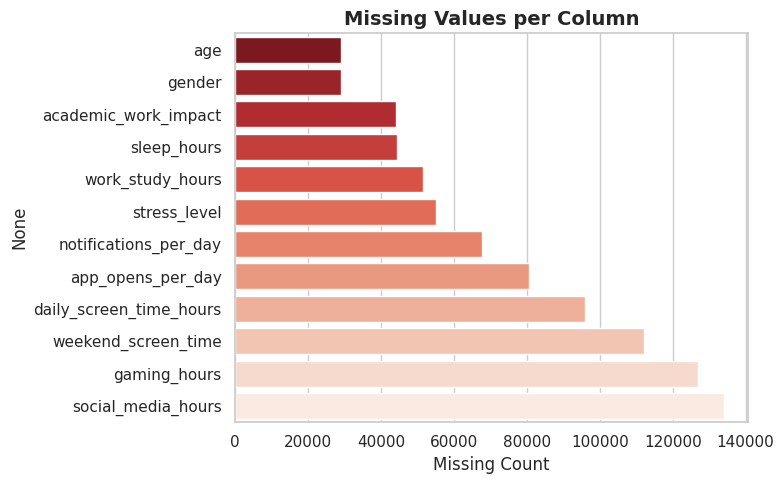

In [7]:
missing_plot = missing[missing > 0].sort_values()
plt.figure(figsize=(8, 5))
sns.barplot(x=missing_plot.values, y=missing_plot.index, palette='Reds_r')
plt.title('Missing Values per Column', fontsize=14, fontweight='bold')
plt.xlabel('Missing Count')
plt.tight_layout()
plt.show()

**Observations:**
- **10 out of 13 features** have missing values — no column is completely clean
- `social_media_hours` has the most missing values (~19.4%), followed by `gaming_hours` (~18.3%) and `weekend_screen_time` (~16.2%)
- No column exceeds **20% missing** — all are recoverable through imputation
- `id` and `addicted_label` have zero missing values

> **Modeling Note:** Imputation will be handled in the modeling notebook using `SimpleImputer` fitted only on train data to avoid data leakage. Median imputation for numerical columns, mode for categorical.

---
## 3. Target Distribution

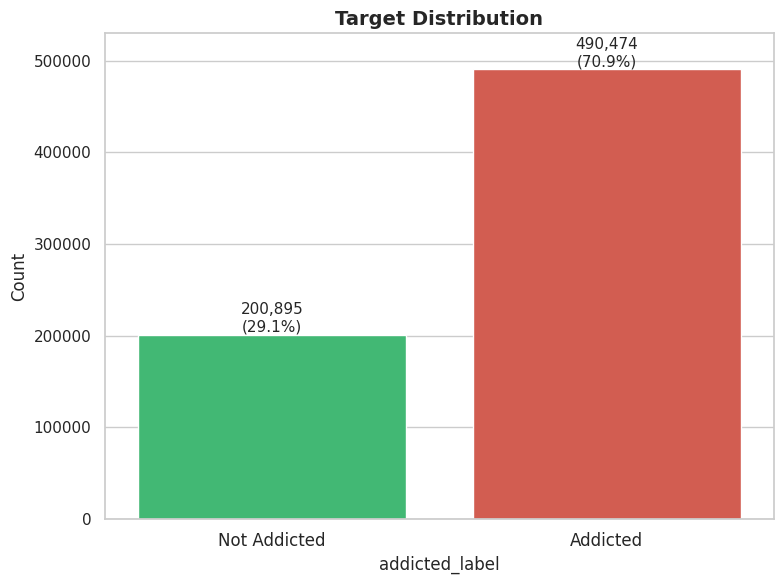

In [8]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    x='addicted_label',
    data=df,
    hue='addicted_label',
    palette=['#2ecc71', '#e74c3c'],
    legend=False
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Not Addicted', 'Addicted'], fontsize=12)

plt.title('Target Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}\n({p.get_height()/len(df)*100:.1f}%)',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

ax.set_ylim(0, max(p.get_height() for p in ax.patches) * 1.08)

plt.tight_layout()
plt.show()

**Observations:**
- The dataset is **imbalanced**: ~70% Addicted vs ~30% Not Addicted
- The minority class is **Not Addicted (0)** — the model will naturally bias toward predicting addiction
- Since the evaluation metric is **ROC-AUC**, which is somewhat robust to imbalance, this isn't critical
- However, `class_weight='balanced'` or `scale_pos_weight` will be applied during modeling to give the minority class more attention

---
## 4. Feature Correlation Analysis

In [9]:
corr = df.corr(numeric_only=True)['addicted_label'].drop('addicted_label').sort_values(ascending=False)
print('Correlation with addicted_label:')
print(corr.round(4))

Correlation with addicted_label:
daily_screen_time_hours    0.6114
weekend_screen_time        0.5899
social_media_hours         0.5324
work_study_hours           0.2514
gaming_hours               0.2053
app_opens_per_day          0.0635
sleep_hours                0.0425
age                        0.0040
notifications_per_day     -0.0116
Name: addicted_label, dtype: float64


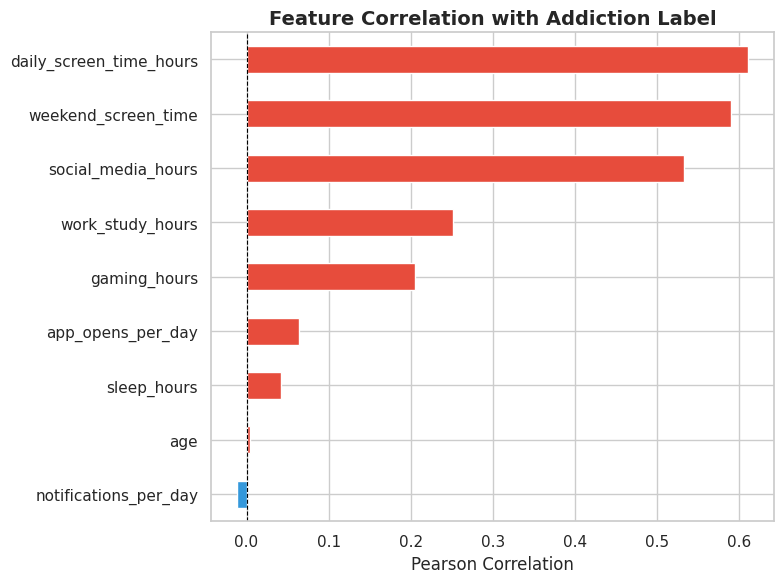

In [10]:
corr_sorted = corr.sort_values()
plt.figure(figsize=(8, 6))
bars = corr_sorted.plot(kind='barh',
                         color=['#e74c3c' if x > 0 else '#3498db' for x in corr_sorted])
plt.title('Feature Correlation with Addiction Label', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

**Observations:**

| Feature | Correlation | Strength |
|---|---|---|
| `daily_screen_time_hours` | 0.611 | 🔥 Very Strong |
| `weekend_screen_time` | 0.590 | 🔥 Very Strong |
| `social_media_hours` | 0.532 | 🔥 Strong |
| `work_study_hours` | 0.251 | ✅ Moderate |
| `gaming_hours` | 0.205 | ✅ Moderate |
| `app_opens_per_day` | 0.063 | ⚠️ Weak |
| `sleep_hours` | 0.042 | ❌ Very Weak |
| `age` | 0.004 | ❌ Negligible |
| `notifications_per_day` | -0.011 | ❌ Negligible |

- **Screen time in all forms dominates prediction** — daily, weekend, and social media screen time are clearly the most informative features
- `sleep_hours` shows near-zero correlation — despite intuition, sleep doesn't strongly distinguish addicted vs non-addicted users in this dataset
- `notifications_per_day` has negligible correlation, though it will be validated through model feature importance before dropping — tree-based models can pick up non-linear patterns that Pearson correlation misses

---
## 5. Deep Dive into Top Features

In [11]:
print('Mean values by addiction label:')
df.groupby('addicted_label').mean(numeric_only=True).T.round(3)

Mean values by addiction label:


addicted_label,0,1
age,26.583,26.629
daily_screen_time_hours,5.043,8.707
social_media_hours,1.376,2.919
gaming_hours,1.160,1.582
work_study_hours,1.873,2.570
sleep_hours,6.722,6.838
notifications_per_day,147.088,145.406
app_opens_per_day,97.871,104.593
weekend_screen_time,6.849,10.559


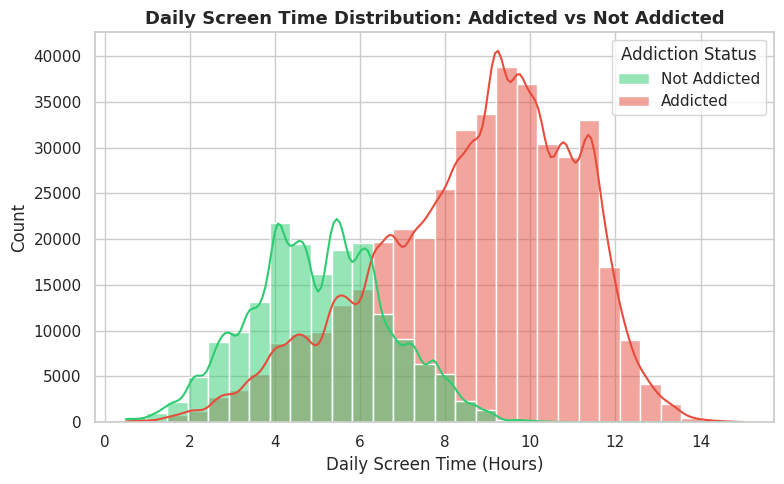

In [12]:
df_plot = df.copy()
df_plot["Addiction Status"] = df_plot["addicted_label"].map({
    0: "Not Addicted",
    1: "Addicted"
})

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_plot,
    x="daily_screen_time_hours",
    hue="Addiction Status",
    hue_order=["Not Addicted", "Addicted"],
    bins=30,
    kde=True,
    palette=["#2ecc71", "#e74c3c"]
)

plt.title("Daily Screen Time Distribution: Addicted vs Not Addicted",
          fontsize=13, fontweight="bold")
plt.xlabel("Daily Screen Time (Hours)")
plt.tight_layout()
plt.show()

**Observations:**
- Non-addicted users (green) are concentrated between **2–6 hours** of daily screen time
- Addicted users (red) dominate above **7 hours**, with a peak around **9–10 hours**
- There's a visible crossover point around **7 hours** — this makes a threshold-based feature a strong candidate for feature engineering

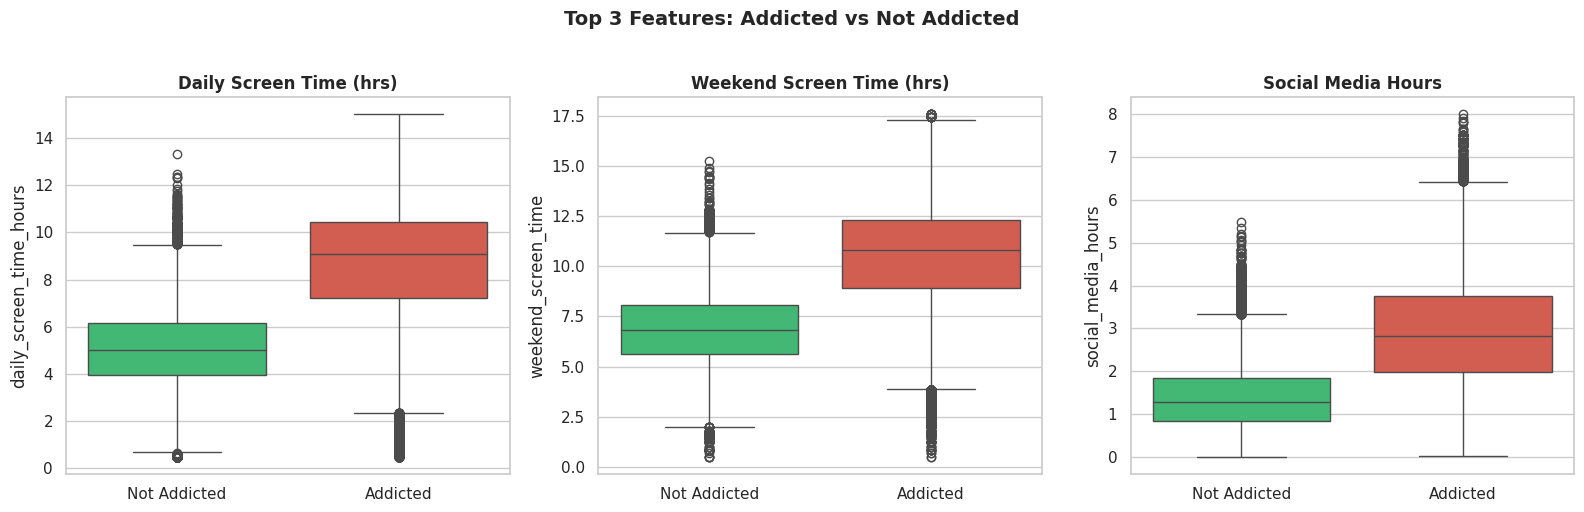

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
top_features = ['daily_screen_time_hours', 'weekend_screen_time', 'social_media_hours']
titles = ['Daily Screen Time (hrs)', 'Weekend Screen Time (hrs)', 'Social Media Hours']

for ax, feat, title in zip(axes, top_features, titles):
    sns.boxplot(x='addicted_label', y=feat, hue='addicted_label',
                data=df, palette=['#2ecc71', '#e74c3c'],
                legend=False, ax=ax)
    ax.set_xticklabels(['Not Addicted', 'Addicted'])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Top 3 Features: Addicted vs Not Addicted', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- All three features show **clear separation** between addicted and non-addicted users
- **Daily Screen Time:** Not addicted median ~5hrs vs addicted median ~9hrs — a ~4hr gap
- **Weekend Screen Time:** Not addicted median ~7hrs vs addicted median ~10hrs
- **Social Media Hours:** Not addicted median ~1.5hrs vs addicted median ~3hrs — double
- The boxplots confirm that screen time across all contexts is the primary driver of addiction prediction

---
## 6. Categorical Features Analysis

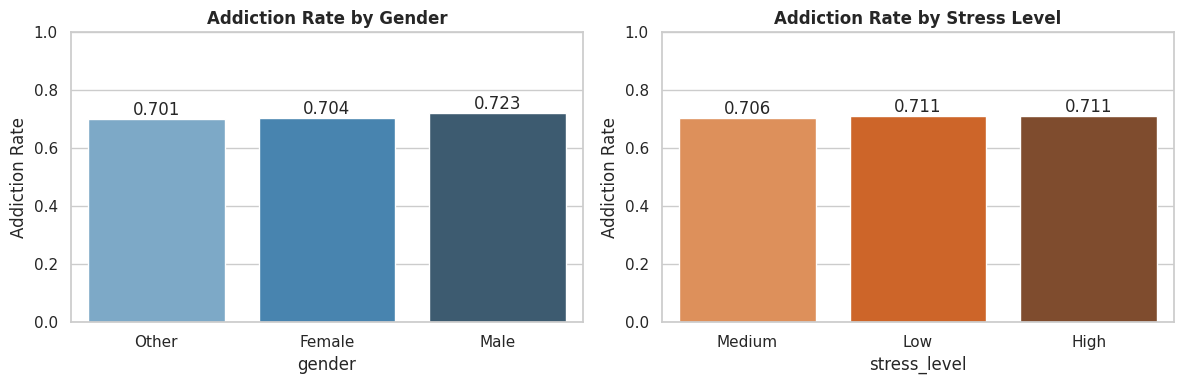

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gender_rates = df.groupby('gender')['addicted_label'].mean().sort_values()
stress_rates = df.groupby('stress_level')['addicted_label'].mean().sort_values()

sns.barplot(x=gender_rates.index, y=gender_rates.values,
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Addiction Rate by Gender', fontweight='bold')
axes[0].set_ylabel('Addiction Rate')
axes[0].set_ylim(0, 1)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.3f}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

sns.barplot(x=stress_rates.index, y=stress_rates.values,
            palette='Oranges_d', ax=axes[1])
axes[1].set_title('Addiction Rate by Stress Level', fontweight='bold')
axes[1].set_ylabel('Addiction Rate')
axes[1].set_ylim(0, 1)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Observations:**
- **Gender:** Female (70.4%), Male (72.3%), Other (70.1%) — all within 2% of each other. Essentially no signal
- **Stress Level:** High (71.1%), Low (71.2%), Medium (70.6%) — again, virtually identical
- Both categorical features carry **minimal predictive power** — the model will likely not rely on them

---
## 7. Feature Engineering

Based on the EDA findings, we engineer new features from the top correlated columns. We apply targeted median imputation only where needed for FE full imputation will be handled properly in the modeling notebook using `SimpleImputer` on train data only.

In [15]:
for col in ['daily_screen_time_hours', 'weekend_screen_time', 'social_media_hours']:
    df[col] = df[col].fillna(df[col].median())

In [16]:
df['high_screen_time_hours'] = (df['daily_screen_time_hours'] > 7).astype(int)
df['high_weekend_screen_time'] = (df['weekend_screen_time'] > 10).astype(int)
df['high_social_media_hours'] = (df['social_media_hours'] > 2).astype(int)

# binning features
df['screen_time_bin'] = pd.cut(
    df['daily_screen_time_hours'],
    bins=[0, 4, 7, 10, 15], labels=[0, 1, 2, 3]
).astype(float)

df['weekend_screen_bin'] = pd.cut(
    df['weekend_screen_time'],
    bins=[0, 5, 10, 13, 18], labels=[0, 1, 2, 3]
).astype(float)

df['social_media_bin'] = pd.cut(
    df['social_media_hours'],
    bins=[0, 1, 2, 4, 8], labels=[0, 1, 2, 3]
).astype(float)

print('New features created:', ['high_screen_time_hours', 'high_weekend_screen_time',
      'high_social_media_hours', 'screen_time_bin', 'weekend_screen_bin', 'social_media_bin'])

New features created: ['high_screen_time_hours', 'high_weekend_screen_time', 'high_social_media_hours', 'screen_time_bin', 'weekend_screen_bin', 'social_media_bin']


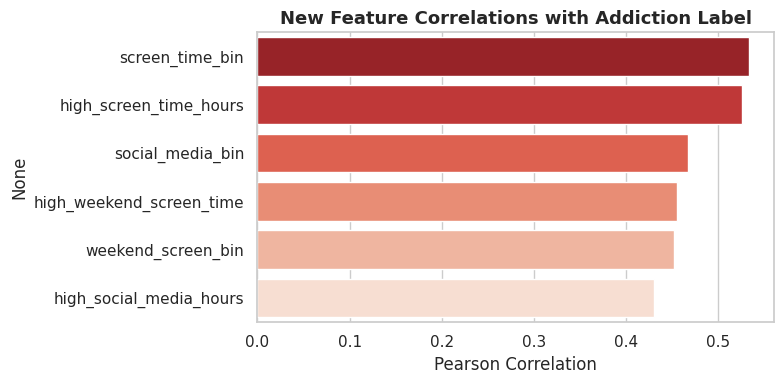

screen_time_bin             0.5335
high_screen_time_hours      0.5255
social_media_bin            0.4672
high_weekend_screen_time    0.4549
weekend_screen_bin          0.4517
high_social_media_hours     0.4296
dtype: float64


In [17]:
fe_features = ['high_screen_time_hours', 'high_weekend_screen_time',
               'high_social_media_hours', 'screen_time_bin',
               'weekend_screen_bin', 'social_media_bin']

fe_corr = df[fe_features].corrwith(df['addicted_label']).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=fe_corr.values, y=fe_corr.index, palette='Reds_r')
plt.title('New Feature Correlations with Addiction Label', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print(fe_corr.round(4))

**Feature Engineering Results:**

| Feature | Type | Correlation |
|---|---|---|
| `screen_time_bin` | Binning | 0.534 |
| `high_screen_time_hours` | Threshold | 0.525 |
| `social_media_bin` | Binning | 0.467 |
| `high_weekend_screen_time` | Threshold | 0.455 |
| `weekend_screen_bin` | Binning | 0.452 |
| `high_social_media_hours` | Threshold | 0.407 |

**Key insights:**
- All 6 engineered features show **correlations above 0.40** — all are meaningful signals
- Binning slightly outperforms threshold for screen time (0.534 vs 0.525), suggesting gradients matter more than a simple cutoff
- These features are **additive** — they complement the original columns rather than replacing them
- Original `daily_screen_time_hours` (0.611) still has the highest correlation, so raw features should be kept alongside engineered ones

---
## 8. Key Takeaways & Conclusions

### What the data tells us:

**Strong Predictors (keep and prioritize):**
- `daily_screen_time_hours` — strongest single feature (corr: 0.61)
- `weekend_screen_time` — very close second (corr: 0.59)
- `social_media_hours` — strong third (corr: 0.53)
- All 6 engineered features (corr: 0.40–0.53)

**Moderate Predictors (include in model):**
- `work_study_hours` (corr: 0.25)
- `gaming_hours` (corr: 0.21)

**Weak/No Signal (validate via model feature importance before dropping):**
- `app_opens_per_day`, `sleep_hours`, `age`, `notifications_per_day`
- `gender`, `stress_level` (categorical — show no variation across groups)

### Missing Data Strategy:
- All columns with missing values are under 20% — use `SimpleImputer` (median for numerical, mode for categorical) fitted only on training data
---
*If you found this notebook helpful, an upvote would be appreciated!*